Best prectis for good consideration
- Rely on the v2 transforms from torchvision.transforms.v2

- Use tensors instead of PIL images (with libriry OpenCV)

- Use torch.uint8 dtype, especially for resizing

- Resize with bilinear or bicubic mode

In [1]:
# tipycal transformer for RGB image 
import torch
from torchvision.transforms import v2
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

transform = v2.Compose([v2.ToImage(),
                        v2.ToDtype(torch.uint8, scale=True) , # scale=True - consider the range of types when converting
                        v2.RandomResizedCrop(size=(224, 224), antialias=True),  # Or Resize(antialias=True)
                        v2.ToDtype(torch.float32, scale=True),  # Normalize expects float input
                        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                        ])

#  Augmentation types 

### Geometric augmentation transformers 

In [2]:
v2.RandomHorizontalFlip(p=0.5)
v2.RandomVerticalFlip(p=0.5)
v2.RandomRotation(degrees=30)
v2.RandomResizedCrop(size=(224, 224)) # Cutting random peas with RANDOM size and then resizing to 244x224
v2.RandomCrop(size=(224, 224)) # Cutting random peas with size 244x224
v2.CenterCrop(size=(224, 224))  
v2.RandomAffine(degrees=15, translate=(0.1, 0.1))
v2.RandomPerspective(distortion_scale=0.5)

RandomPerspective(p=0.5, distortion_scale=0.5, interpolation=InterpolationMode.BILINEAR, fill=0)

### Calloring augmentation

In [3]:
v2.ColorJitter(
    brightness=0.2,
    contrast=0.2,
    saturation=0.2,
    hue=0.1
)
v2.RandomGrayscale(p=0.1)
v2.GaussianBlur(kernel_size=3)
v2.RandomSolarize(threshold=128)
v2.RandomEqualize(p=0.5)
v2.RandomAutocontrast(p=0.5)

RandomAutocontrast(p=0.5)

### Regularisation  Augmentation

In [4]:
v2.RandomErasing(p=0.5)        # случайно затирает прямоугольник
# v2.RandomMixup(alpha=0.2)      # смешивает два изображения
# v2.RandomCutmix(alpha=1.0)     # вырезает и вставляет кусок из другого

RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=[0.0], inplace=False)

Let's try do somthing augmentation

In [5]:
plt.rcParams["savefig.bbox"] = 'tight'

# if you change the seed, make sure that the randomly-applied transforms
# properly show that the image can be both transformed and *not* transformed!
torch.manual_seed(0)

orig_img = Image.open('baleine.jpg')
transform = v2.ToImage()
transf_img = transform(orig_img)
print(type((orig_img)))
print(type((transf_img)))


<class 'PIL.JpegImagePlugin.JpegImageFile'>
<class 'torchvision.tv_tensors._image.Image'>


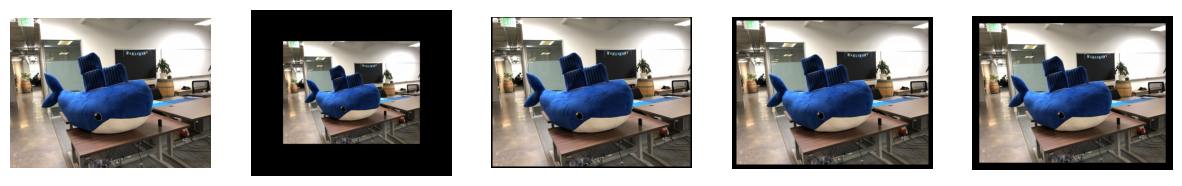

In [12]:
padded_imgs = [v2.Pad(padding=padding)(transf_img) for padding in (300, 10, 30, 50)]
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, img in zip(axes, [transf_img] + padded_imgs):
    ax.imshow(img.permute(1, 2, 0))  # C,H,W → H,W,C для matplotlib
    ax.axis('off')
plt.show()

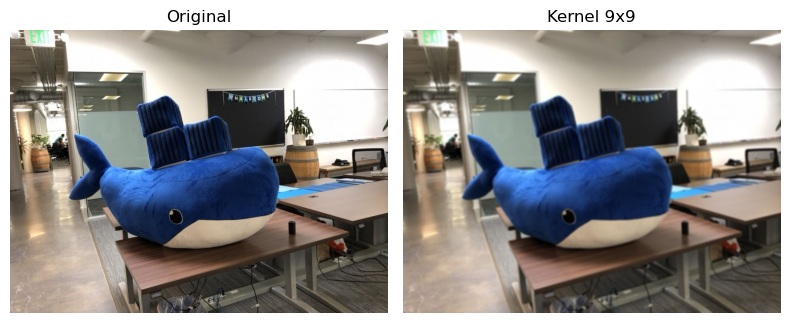

gaussian_imgs size = torch.Size([3, 960, 1280]) 
  true_img size torch.Size([3, 960, 1280])


In [77]:
gaussian_imgs = v2.GaussianBlur(kernel_size = 9, sigma=(3.0))
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
# axes_flat = axes.ravel()  # Converts the 2x2 grid into a 1D list of 4 elements

# 2. Combine the original image and the blurred images into one list
g_img = [transf_img, gaussian_imgs(transf_img)]

# 3. Titles for better scannability
titles = ["Original", "Kernel 9x9"] # It's mean that the picters cuts on squers 9x9 for all his picsels a

# 4. Loop through axes, images, and titles simultaneously
for ax, img, title in zip(axes,g_img, titles):
    # Permute converts PyTorch (C, H, W) to Matplotlib (H, W, C)
    ax.imshow(img.permute(1, 2, 0).cpu())  
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()
print(f'gaussian_imgs size = {(gaussian_imgs(transf_img)).shape} \n  true_img size {transf_img.shape}')

Нужно понимать что размер ядра должен зависить от кол-ва пикселей картинки 1% для очень слабого размытия 5% для сдруднего и 8-12% для не различимого , при этом сигма - отклонение высчитывется по правилу 3х сигм , то есть центральный пиксель есть смесь затухания блидайших , чем пиксель ближн тнм больше его влияние 

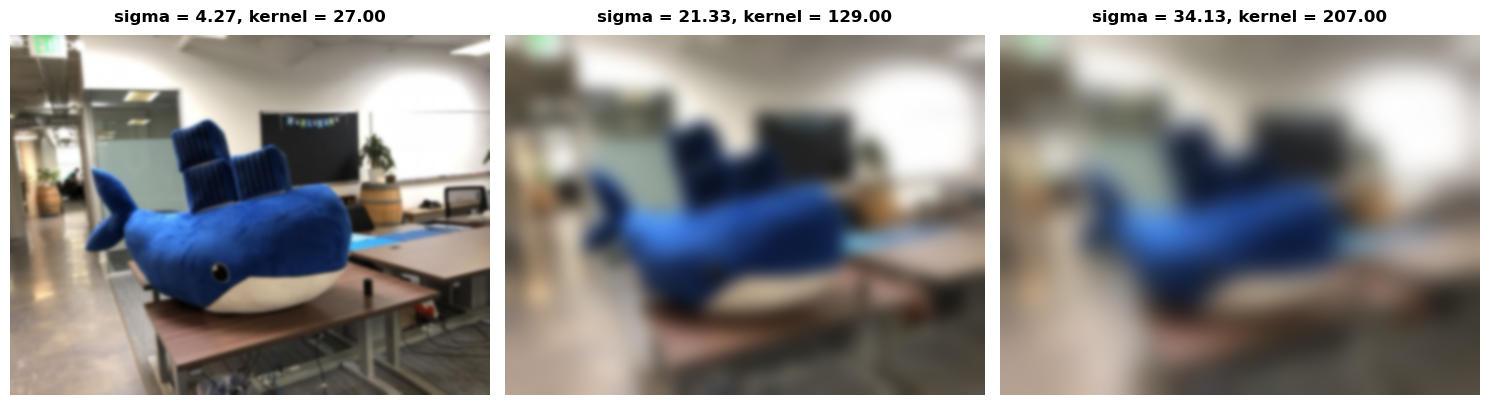

In [79]:
import math
from torchvision.transforms import v2

# Допустим, к нам пришла большая картинка 
# Её форма в PyTorch: [Channels, Height, Width]
width = transf_img.shape[2] 

# Мы хотим сильное размытие заднего плана (5% от ширины экрана)
blur_percentage = [0.01, 0.05, 0.08]
desired_radius = [(width * bl_p) for bl_p in blur_percentage]  # [12.8, 64.0, 102.4]
#  Рассчитываем идеальную Сигму по правилу трех сигм (radius = 3 * sigma)
sigma_ideal = [(d_r / 3.0) for d_r in desired_radius] # [4.266, 21.333 34.133]

#  Рассчитываем идеальный размер ядра (Kernel = 2 * radius + 1)
# Делаем число гарантированно нечетным
kernel_ideal = [int(2 * math.ceil(d_r) + 1) for d_r in desired_radius]

titles = [f'sigma = {(sigma_ideal[i]):.2f}, kernel = {(kernel_ideal[i]):.2f}' for i in range(3)]

#  Применяем идеально сбалансированный фильтр
blur_filter = [v2.GaussianBlur(kernel_size=k_i, sigma=s_i)(transf_img) for k_i,s_i in zip(kernel_ideal,sigma_ideal)]
fig, axis = plt.subplots(1,3,  figsize=(15, 6))
for ax , img , titl in zip(axis, blur_filter, titles):
    ax.imshow(img.permute(1, 2, 0).cpu())
    ax.set_title(titl, fontsize=12, pad=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()


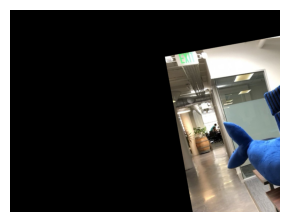

In [101]:
affin_img  = v2.RandomAffine(degrees=25, translate=(0.7, 0.3))(transf_img)
plt.figure(figsize=(3,3))
plt.imshow(affin_img.permute(1, 2, 0).cpu())
plt.axis('off')
plt.tight_layout()
plt.show()


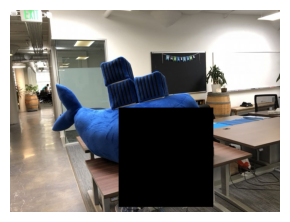

In [110]:
tringl_im = v2.RandomErasing(p=0.5)(transf_img)        # случайно затирает прямоугольник
plt.figure(figsize=(3,3))
plt.imshow(tringl_im.permute(1, 2, 0).cpu())
plt.axis('off')
plt.tight_layout()
plt.show()


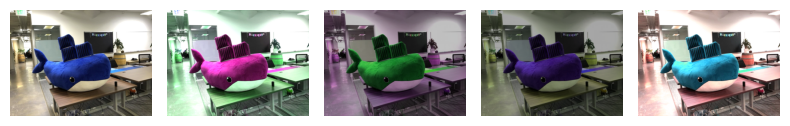

In [132]:
random_color_im = v2.ColorJitter(brightness=.5, hue=.3)
random_color_im = [random_color_im(transf_img) for i in range (5)]
fig, axes = plt.subplots(1,5, figsize=(8, 4))
for ax, img in zip(axes, random_color_im):
    ax.imshow(img.permute(1, 2, 0).cpu())
    ax.axis('off')

plt.tight_layout()
plt.show()